# Tarea 4 - Punto 2: Robot Repartidor de Galletas
En este notebook implementamos un algoritmo de Programación Genética para entrenar a un robot a repartir galletas a ingenieros en una sala cuadrada.


In [1]:
!pip install deap matplotlib numpy


## 1. Definición del Entorno
Simularemos una sala de 10x10 donde el robot inicia en la posición (0,0) y los ingenieros están repartidos aleatoriamente.


In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, gp
import operator

# Tamaño de la sala e ingenieros
GRID_SIZE = 10
NUM_ENGINEERS = 15

class Simulator:
    def __init__(self, seed=None):
        if seed is not None:
            random.seed(seed)
        self.grid = np.zeros((GRID_SIZE, GRID_SIZE))
        # Colocar ingenieros (representados por 1)
        engineers_placed = 0
        while engineers_placed < NUM_ENGINEERS:
            x, y = random.randint(0, GRID_SIZE-1), random.randint(0, GRID_SIZE-1)
            if self.grid[y, x] == 0:
                self.grid[y, x] = 1
                engineers_placed += 1
        self.robot_pos = [0, 0]
        self.robot_dir = 0 # 0: derecha, 1: abajo, 2: izquierda, 3: arriba
        self.cookies_delivered = 0
        self.steps = 0
        self.max_steps = 200
        self.path = [(0,0)]

    def get_forward_pos(self):
        x, y = self.robot_pos
        if self.robot_dir == 0: x += 1
        elif self.robot_dir == 1: y += 1
        elif self.robot_dir == 2: x -= 1
        elif self.robot_dir == 3: y -= 1
        return [x, y]

    def is_engineer_ahead(self):
        fx, fy = self.get_forward_pos()
        if 0 <= fx < GRID_SIZE and 0 <= fy < GRID_SIZE:
            return self.grid[fy, fx] == 1
        return False

    def move_forward(self):
        if self.steps >= self.max_steps: return
        self.steps += 1
        fx, fy = self.get_forward_pos()
        if 0 <= fx < GRID_SIZE and 0 <= fy < GRID_SIZE:
            self.robot_pos = [fx, fy]
            self.path.append(tuple(self.robot_pos))
            if self.grid[fy, fx] == 1:
                self.grid[fy, fx] = 0 # Entregó galleta
                self.cookies_delivered += 1

    def turn_left(self):
        if self.steps >= self.max_steps: return
        self.steps += 1
        self.robot_dir = (self.robot_dir - 1) % 4

    def turn_right(self):
        if self.steps >= self.max_steps: return
        self.steps += 1
        self.robot_dir = (self.robot_dir + 1) % 4


## 2. Definición de la Programación Genética (DEAP)
Definimos el conjunto de terminales (acciones) y funciones (control de flujo).


In [3]:
# Funciones de envoltorio (wrapper) para el control de flujo en el árbol sintáctico
import functools
def progn(*args):
    for arg in args:
        arg() # Ejecuta las funciones que recibe

def prog2(out1, out2):
    return functools.partial(progn, out1, out2)

def prog3(out1, out2, out3):
    return functools.partial(progn, out1, out2, out3)

# La implementación de PG requiere que las primitivas manipulen el simulador.
# Para evitar problemas de ámbito de DEAP, usaremos funciones con estado global.
import copy

current_sim = None

def m_move():
    global current_sim
    if current_sim: current_sim.move_forward()

def m_left():
    global current_sim
    if current_sim: current_sim.turn_left()

def m_right():
    global current_sim
    if current_sim: current_sim.turn_right()

def m_sense():
    global current_sim
    return current_sim.is_engineer_ahead() if current_sim else False

def m_if(out1, out2):
    def wrapper():
        if m_sense(): out1()
        else: out2()
    return wrapper

# DEAP setup
pset = gp.PrimitiveSet("MAIN", 0)
pset.addPrimitive(prog2, 2, name="prog2")
pset.addPrimitive(prog3, 3, name="prog3")
pset.addPrimitive(m_if, 2, name="if_engineer_ahead")
pset.addTerminal(m_move, name="Avanzar")
pset.addTerminal(m_left, name="GirarIzq")
pset.addTerminal(m_right, name="GirarDer")

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("expr_init", gp.genHalfAndHalf, pset=pset, min_=1, max_=2)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr_init)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)


Ahora definimos la evaluación global del robot.


In [4]:
def evalRobotGlobal(individual):
    global current_sim
    routine = gp.compile(individual, pset)
    current_sim = Simulator()
    
    while current_sim.steps < current_sim.max_steps and current_sim.cookies_delivered < NUM_ENGINEERS:
        routine()
        
    return current_sim.cookies_delivered,

toolbox.register("evaluate", evalRobotGlobal)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("expr_mut", gp.genFull, min_=0, max_=2)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)


## 3. Entrenamiento
Ejecutamos el algoritmo genético para evolucionar el mejor comportamiento del robot.


In [5]:
from deap import algorithms

pop = toolbox.population(n=100)
hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

print("Iniciando evolución...")
pop, logbook = algorithms.eaSimple(pop, toolbox, 0.5, 0.1, 40, stats=stats, halloffame=hof, verbose=True)
print("¡Evolución terminada!")


Iniciando evolución...
gen	nevals	avg	std    	min	max
0  	100   	0.5	1.28452	0  	11 
1  	53    	1.08	1.38333	0  	8  
2  	50    	1.55	1.70514	0  	8  
3  	57    	2.04	1.95918	0  	8  
4  	68    	1.87	1.67126	0  	8  
5  	49    	2.68	2.09705	0  	9  
6  	55    	2.88	2.38445	0  	9  
7  	58    	2.79	2.15079	0  	9  
8  	49    	3.03	2.45542	0  	9  
9  	56    	3.62	2.50112	0  	10 
10 	54    	3.93	2.78659	0  	12 
11 	62    	4.27	3.23065	0  	12 
12 	62    	4.36	3.15443	0  	12 
13 	53    	4.6 	3.41467	0  	12 
14 	45    	5.5 	3.74032	0  	12 
15 	52    	6.01	4.08043	0  	12 
16 	65    	5.85	4.19613	0  	12 
17 	52    	6.43	4.38236	0  	12 
18 	62    	5.76	4.31768	0  	12 
19 	62    	6.85	4.17223	0  	13 
20 	59    	6.43	3.75834	0  	13 
21 	57    	6.79	3.91228	0  	14 
22 	55    	6.84	3.94391	0  	14 
23 	40    	8.32	3.88299	0  	14 
24 	66    	7.13	4.10282	0  	14 
25 	57    	7.31	4.41066	0  	15 
26 	61    	7.5 	4.53321	0  	15 
27 	57    	8.81	4.13206	0  	15 
28 	53    	9.77	4.00463	0  	15 
29 	55    	10.19	3.

## 4. Visualización del mejor individuo


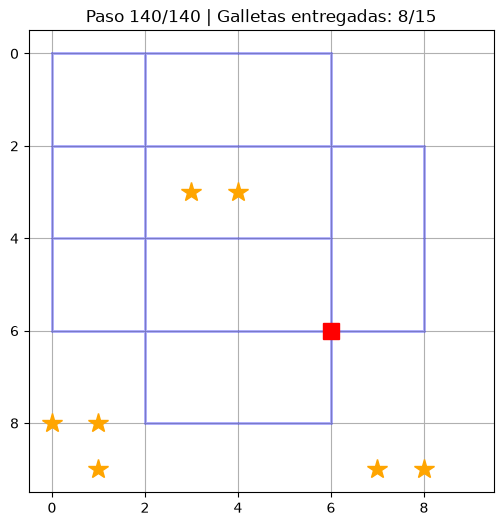

¡Recorrido finalizado!


In [6]:
import time
from IPython.display import clear_output

best_ind = hof[0]
print("Mejor programa genético:\n", best_ind)

# Simulamos con una semilla fija para poder ver exactamente qué hizo el robot
seed_test = 42
current_sim = Simulator(seed=seed_test)
original_grid = current_sim.grid.copy()

routine = gp.compile(best_ind, pset)
while current_sim.steps < current_sim.max_steps and current_sim.cookies_delivered < NUM_ENGINEERS:
    routine()

print(f"Galletas entregadas: {current_sim.cookies_delivered}/{NUM_ENGINEERS} en {current_sim.steps} pasos")
print("Preparando visualización en vivo...")
time.sleep(2)

# Reproducir el camino en vivo
path = current_sim.path
live_grid = original_grid.copy()

for i in range(len(path)):
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(6,6))
    
    # Dibujar ingenieros restantes
    for y in range(GRID_SIZE):
        for x in range(GRID_SIZE):
            if live_grid[y, x] == 1:
                ax.plot(x, y, marker='*', color='orange', markersize=15)
                
    rx, ry = path[i]
    if live_grid[ry, rx] == 1:
        live_grid[ry, rx] = 0 # Entregó galleta en la animación
        
    # Dibujar camino recorrido
    if i > 0:
        p_arr = np.array(path[:i+1])
        ax.plot(p_arr[:,0], p_arr[:,1], color='blue', alpha=0.3, linewidth=2)
        
    # Dibujar robot
    ax.plot(rx, ry, marker='s', color='red', markersize=12)
    
    ax.set_xlim(-0.5, GRID_SIZE-0.5)
    ax.set_ylim(-0.5, GRID_SIZE-0.5)
    ax.invert_yaxis()
    ax.set_title(f"Paso {i}/{len(path)-1} | Galletas entregadas: {NUM_ENGINEERS - int(np.sum(live_grid))}/{NUM_ENGINEERS}")
    ax.grid(True)
    
    plt.show()
    time.sleep(0.1)

print("¡Recorrido finalizado!")
